In [ ]:
# Installation des packages
#%pip install -r requirements.txt

# Importations de librairies essentielles
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
import torch
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Chargement et préparation des données

In [45]:
def load_data(file_path):
    """
    Charge les données depuis un fichier CSV et crée un identifiant unique pour chaque verbatim.
    """
    try:
        data = pd.read_csv(file_path, sep=";", encoding="utf-8",header=0)

        return data
    except Exception as e:
        print(f"Erreur lors du chargement des données : {e}")
        return None


In [46]:
verbatims_df = load_data(file_path="data/verbatims_nps_C0.csv")


In [54]:
pd.set_option("display.max_colwidth", None)

verbatims_df.head(20)

,id,commentaire
0,0,"après coup, je me suis rendu compte d'erreurs sur le contrat automobile"
1,1,"même en tant qu'employé, le prix de l'assurance auto est le double de vos concurrents. j'imagine le tarif pour un client normal."
2,2,très bien mais les prix ne sont pas compétitifs
3,3,jamais la bonne personne en ligne délais de réponse plutôt long
4,4,"le service client est très bien et me convient. cependant, les coûts d'assurance restent à l'appréciation de tout un chacun"
5,5,l'assurance protection juridique est à prendre à la pincette.
6,6,"même exacte, selon les cg de mon contrat auto, la réponse donnée n'était pas celle que j'attendais."
7,7,"le service client est très à l'écoute, patient, prend en compte vos demandes et propose des alternatives lorsque c'est nécessaire. récapitule vos demandes et nous demande confirmation et si l'on a d'autres questions. pas trop de temps d'attente pour avoir un conseiller. tout était parfait. merci"
8,8,"assurance auto trop chère, mais réponse et explications des opérateurs très bonne"
9,9,je n'ai pas été satisfait par l'assurance protection juridique.


# 2. Conversion du texte en vecteurs avec un model d'embedding Hugging Face

## 2.1 Telecharger un modele d'embedding depuis Hugging face et le stocker en local
### On telecharge 2 modeles  : un modele specialisé sur du français "OrdalieTech/Solon-embeddings-base-0.1" et un modele multilingue plus petit et generaliste sentence-transformers/all-MiniLM-L6-v2"


In [47]:

model_name = "OrdalieTech/Solon-embeddings-base-0.1"
#model_name = "sentence-transformers/all-MiniLM-L6-v2"


In [48]:
from huggingface_hub import snapshot_download

path = snapshot_download(
    repo_id=model_name,
    local_dir=f"./models/{model_name}",
    local_dir_use_symlinks=False
)
print("Downloaded to:", path)

/Users/aquereburukent/Documents/projets/isup_ai/aidemo/lib/python3.10/site-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(
Fetching 13 files: 100%|██████████| 13/13 [00:09<00:00,  1.34it/s]

Downloaded to: /Users/aquereburukent/Documents/projets/isup_ai/models/OrdalieTech/Solon-embeddings-base-0.1


### 2.2 Calcul des embeddings pour chaque verbatim

In [50]:


def pick_device():
    return "cuda" if torch.cuda.is_available() else "cpu"

def compute_embeddings(verbatims_list, model_path, device="cuda"):
    """
    Charge un modèle d'embeddings et calcule les embeddings des verbatims.
    """
    try:
        model = SentenceTransformer(model_path)
    except Exception as e:
        print(f"Erreur lors du chargement du modèle d'embeddings : {e}")
        return None
    
    embeddings = model.encode(verbatims_list, show_progress_bar=True, device=pick_device())
    return embeddings

In [55]:
embedding_model_path = f"./models/{model_name}"
embedding_model_path, pick_device()


('./models/OrdalieTech/Solon-embeddings-base-0.1', 'cpu')

In [58]:
# Calcul des embeddings
print("Calcul des embeddings...")
embeddings = compute_embeddings(verbatims_list=verbatims_df["commentaire"].tolist(), model_path=embedding_model_path)
embeddings.shape # Matrice de dimension 50*768 : Chaque verbatim est represente par un vecteur dembedding de 768 dimensions

Calcul des embeddings...


Batches: 100%|██████████| 2/2 [00:00<00:00,  6.35it/s]


(50, 768)

###  2.3 Optionnel : Alternative aux embedding, on peut calcul un score TF IDF classique...

In [ ]:
# 3. Calcul de la matrice TF-IDF et de la similarité cosinus


def compute_tfidf_similarity(verbatims):
    """
    Calcule la transformation TF-IDF des verbatims puis la similarité cosinus entre chaque paire.
    """
    
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(verbatims)
    df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

    similarity_matrix = cosine_similarity(tfidf_matrix)
    
    return df_tfidf, similarity_matrix, vectorizer

In [63]:
# Calcul de la matrice TF-IDF et de la similarité
print("Calcul de la similarité TF-IDF...")
df_tfidf, similarity_matrix, vectorizer = compute_tfidf_similarity(verbatims=verbatims_df["commentaire"].tolist())

print("La representation vectorielle tf idf : Mots en colonne et verbatims en ligne")
print("Cette methode necessite un nettoyage classique du texte pr le normaliser : suppression stopwords, racinitation, etc")
df_tfidf


Calcul de la similarité TF-IDF...
La representation vectorielle tf idf : Mots en colonne et verbatims en ligne
Cette methode necessite un nettoyage classique du texte pr le normaliser : suppression stopwords, racinitation, etc


,41,abordable,absolument,accueil,acquis,actuellement,adaptée,age,agréable,ai,...,ya,écoute,égales,élevé,élevée,énormément,épuisant,était,été,être
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.238437,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.135728,0.000000,0.000000,0.000000,0.000000,0.000000,0.135728,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.317797,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.492592,0.000000


# 4. Réduction de dimensions (ACP) et clustering (Kmeans ou DBSCAN)

In [95]:

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans

def perform_clustering(embeddings, method="dbscan", eps=0.1, min_samples=2, n_clusters=3, n_components=2):
    """
    Réduit la dimension des embeddings via PCA puis réalise un clustering.
    method : "dbscan" ou "kmeans"
    """
    
    pca = PCA(n_components=n_components)
    embeddings_2d = pca.fit_transform(embeddings)

    if method == "dbscan":
        model = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine")
    
    elif method == "kmeans":
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    else:
        raise ValueError("method doit être 'dbscan' ou 'kmeans'")

    clusters = model.fit_predict(embeddings_2d)

    return embeddings_2d, clusters, pca

In [97]:
embeddings_2d, clusters, pca = perform_clustering(
    embeddings,
    method="kmeans",
    n_clusters=5
)
# Ajout de la colonne "cluster" dans le dataset original
verbatims_df["cluster"] = clusters


In [100]:

verbatims_df

,id,commentaire,cluster
0,0,"après coup, je me suis rendu compte d'erreurs sur le contrat automobile",1
1,1,"même en tant qu'employé, le prix de l'assurance auto est le double de vos concurrents. j'imagine le tarif pour un client normal.",1
2,2,très bien mais les prix ne sont pas compétitifs,4
3,3,jamais la bonne personne en ligne délais de réponse plutôt long,2
4,4,"le service client est très bien et me convient. cependant, les coûts d'assurance restent à l'appréciation de tout un chacun",4
5,5,l'assurance protection juridique est à prendre à la pincette.,3
6,6,"même exacte, selon les cg de mon contrat auto, la réponse donnée n'était pas celle que j'attendais.",1
7,7,"le service client est très à l'écoute, patient, prend en compte vos demandes et propose des alternatives lorsque c'est nécessaire. récapitule vos demandes et nous demande confirmation et si l'on a d'autres questions. pas trop de temps d'attente pour avoir un conseiller. tout était parfait. merci",0
8,8,"assurance auto trop chère, mais réponse et explications des opérateurs très bonne",4
9,9,je n'ai pas été satisfait par l'assurance protection juridique.,3


### 5 Comment interpréter les clusters ? (
#### 5.1 Methode classique et Methode recente avec LLM)

In [121]:

def plot_cluster_counts(data, cluster_column="cluster"):
    """
    Affiche un graphique en barres du nombre d'éléments par cluster.
    """
    cluster_counts = data[cluster_column].value_counts().sort_index()
    cluster_counts_df = cluster_counts.reset_index()
    cluster_counts_df.columns = ["Cluster", "Count"]

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Cluster", y="Count", data=cluster_counts_df, palette="viridis")
    plt.title("Nombre d'éléments par Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Nombre d'éléments")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_clusters(embeddings_2d, clusters):
    """
    Affiche un scatter plot des verbatims réduits en dimensions 2D, coloré selon le cluster.
    """
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        embeddings_2d[:, 0], embeddings_2d[:, 1], c=clusters, cmap="viridis", marker="o"
    )
    plt.title("Distribution des verbatims - Clustering")
    plt.xlabel("PCA composante 1")
    plt.ylabel("PCA composante 2")
    plt.colorbar(scatter, label="Cluster ID")
    plt.tight_layout()
    plt.show()


def print_cluster_verbatims(data, cluster_column="cluster", text_column="commentaire"):
    """
    Affiche dans la console les verbatims pour chaque cluster
    avec un espace entre chaque verbatim.
    """
    unique_clusters = data[cluster_column].unique()

    for cluster_id in sorted(unique_clusters):
        cluster_verbatims = data[data[cluster_column] == cluster_id][text_column].tolist()

        print(f"\nCluster {cluster_id}")
        print("-" * 40)

        print("\n\n".join(cluster_verbatims))


/var/folders/d6/cqs74t7d6s505nh8t9f2df0w0000gn/T/ipykernel_79586/2222190496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Cluster", y="Count", data=cluster_counts_df, palette="viridis")


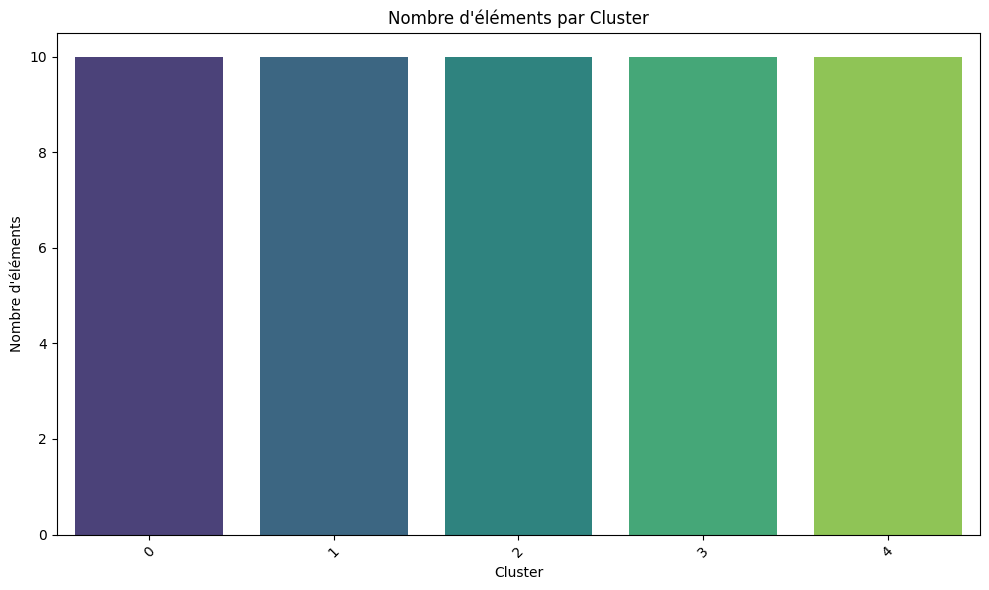

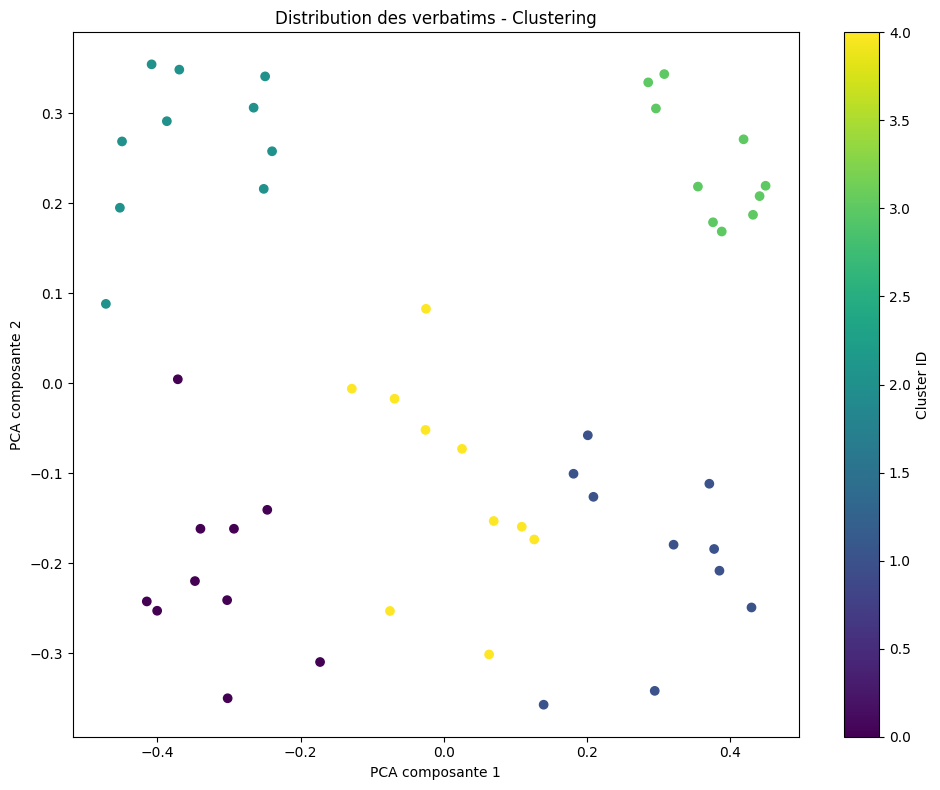

In [122]:
# Visualisations
plot_cluster_counts(data=verbatims_df)
plot_clusters(embeddings_2d, clusters)




#### 5.2 Detecter le verbatim representant chaque cluster : ie le plus proche du centre

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

def get_representative_verbatims(df, embeddings, cluster_col="cluster", text_col="commentaire", top_n=2):
    result = {}


    for cluster in sorted(df[cluster_col].dropna().unique()):
        # Excepption pour le cluster outlier de dbscan, pas utile si Kmeans 
        if cluster == -1:
            continue

        mask = df[cluster_col] == cluster
        cluster_embeddings = embeddings[mask]
        centroid = cluster_embeddings.mean(axis=0, keepdims=True)

        distances = cosine_distances(cluster_embeddings, centroid).ravel()
        top_idx = distances.argsort()[:top_n]

        result[int(cluster)] = df.loc[mask, text_col].iloc[top_idx].tolist()

    return result

In [133]:
representatifs = get_representative_verbatims(df=verbatims_df, embeddings=embeddings)
representatifs

{np.int32(0): ["l'accueil, l'écoute et la bienveillance du service client était très agréable. ",
  'parce que le service client est très agréable '],
 np.int32(1): ["car j'ai était déçu a la suite de la résiliation de mon contrat assurance voiture ",
  'pas du tout satisfait suite à mon contrat assurance voiture'],
 np.int32(2): ["qualité de la réponse et délai d'attente ",
  'temps de réponse rapide très agréable '],
 np.int32(3): ["je n'ai pas été satisfait par l'assurance protection juridique. ",
  "parceque suis pas satisfait de vos services juridiques, j'ai demandé une protection et ya eu refus de prise en charge par vos juriste alors que c'est notifié dans les garanties de protection juridique, "],
 np.int32(4): ["le service client est très bien et me convient. cependant, les coûts d'assurance restent à l'appréciation de tout un chacun",
  'je trouve les prix un peu élevé par rapport à la concurrence.']}

In [123]:
print_cluster_verbatims(data=verbatims_df, cluster_column="cluster", text_column="commentaire")




Cluster 0
----------------------------------------
le service client est très à l'écoute, patient,  prend en compte vos demandes et propose des alternatives lorsque c'est nécessaire. récapitule vos demandes et nous demande confirmation et si l'on a d'autres questions. pas trop de temps d'attente pour avoir un conseiller. tout était parfait. merci

le service client est exceptionnel 

l'accueil, l'écoute et la bienveillance du service client était très agréable. 

le service client très bien, juste les tarifs ne sont pas du tout compétitifs à conditions égales 

j'apprécie beaucoup le service client et aussi l'assurance 

j'ai toujours eu un bon contact avec le service client les personnes sont aimables .... lerci

parce que le service client est très agréable 

je suis très satisfait du service client 

réponses claires precises personne tres aimables le service client est tellement important

le service client est exceptionnel, ils ont tous une très bonne elocution, comprennent très 

In [124]:
from sklearn.feature_extraction.text import CountVectorizer

french_stop_words = [
    "le", "la", "les", "de", "des", "du", "un", "une", "et", "à", "en",
    "dans", "sur", "pour", "par", "avec", "sans", "au", "aux", "ce",
    "cet", "cette", "ces", "qui", "que", "quoi", "dont", "où", "ne",
    "pas", "plus", "très", "trop", "être", "avoir", "faire", "car",
    "comme", "mais", "ou", "donc", "est", "je","mon"
]

def keywords_by_cluster(df, text_col="verbatim", cluster_col="cluster",top_n=5,stop_words=french_stop_words):
    result = {}
    
    for c, g in df.groupby(cluster_col):
        vec = CountVectorizer(stop_words=stop_words, ngram_range=(1,2))
        X = vec.fit_transform(g[text_col].fillna("").astype(str))
        
        words = vec.get_feature_names_out()
        scores = X.sum(axis=0).A1
        top = scores.argsort()[::-1][:top_n]
        
        result[c] = [words[i] for i in top]

    return result

In [ ]:
keywords = keywords_by_cluster(df=verbatims_df,text_col="commentaire",cluster_col="cluster",top_n=5)
keywords


{0: ['service client', 'client', 'service', 'toujours', 'tout'],
 1: ['assurance', 'contrat', 'auto', 'automobile', 'résiliation contrat'],
 2: ['réponse', 'temps', 'attente', 'long', 'temps attente'],
 3: ['juridique', 'protection', 'assurance', 'protection juridique', 'ai'],
 4: ['concurrence', 'assurance', 'rapport', 'tarif', 'rapport concurrence']}

### 5.2 Méthode avec LLM  : Idee : Générer un résumé de chaque cluster par LLM ? 
